In [1]:
!pip install --upgrade xee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 476.6/476.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.7 MB/s eta 0:00:00
  Attempting uninstall: earthengine-api
    Found existing installation: earthengine-api 1.5.24
    Uninstalling earthengine-api-1.5.24:
      Successfully uninstalled earthengine-api-1.5.24


In [2]:
!pip install -U geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.9 MB/s eta 0:00:00
  Attempting uninstall: geemap
    Found existing installation: geemap 0.35.3
    Uninstalling geemap-0.35.3:
      Successfully uninstalled geemap-0.35.3


In [3]:
import ee

In [4]:
ee.Authenticate()
ee.Initialize(project = "ee-grmntfrancis0",
              opt_url='https://earthengine-highvolume.googleapis.com')

In [5]:
import geemap

In [6]:
map = geemap.Map()
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [7]:
point = map.draw_last_feature.geometry()
point

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Point",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      30.799507,
                      6.664304
                    ]
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

In [10]:
border = (
    ee.FeatureCollection("FAO/GAUL/2015/level0")
    .filterBounds(point)
    .geometry().simplify(100)
)

In [ ]:
vec = geemap.ee_to_gdf(ee.FeatureCollection(ee.Feature(border)))
vec

In [11]:
map.addLayer(border, {}, "boder")

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
import xee
import geopandas as gpd


In [63]:
vec = geemap.ee_to_gdf(ee.FeatureCollection(ee.Feature(border)))
vec

,geometry
0,GEOMETRYCOLLECTION (LINESTRING (30.85418 3.487...


<Axes: >

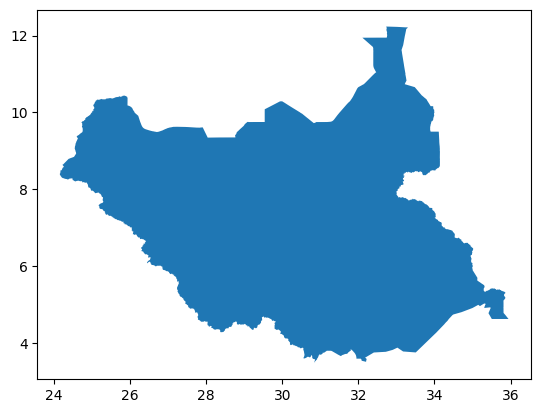

In [67]:
vec.plot()

In [68]:
vec.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [69]:
vec.geometry

,geometry
0,GEOMETRYCOLLECTION (LINESTRING (30.85418 3.487...


In [71]:
ds_rename = ds.rename({"lon": "x", "lat": "y"})

In [74]:
!pip install rioxarray rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.6 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [75]:
import rioxarray as rxr

In [77]:
ds_clip = ds_rename.rio.clip(vec.geometry, vec.crs)
ds_clip

<xarray.Dataset> Size: 330kB
Dimensions:      (time: 1, x: 118, y: 87)
Coordinates:
  * time         (time) int64 8B 0
  * x            (x) float64 944B 24.2 24.3 24.4 24.5 ... 35.6 35.7 35.8 35.9
  * y            (y) float64 696B 3.537 3.637 3.737 3.837 ... 11.94 12.04 12.14
    spatial_ref  int64 8B 0
Data variables:
    ndvi         (time, x, y) float32 41kB nan nan nan nan ... nan nan nan nan
    evi          (time, x, y) float32 41kB nan nan nan nan ... nan nan nan nan
    lai          (time, x, y) float32 41kB nan nan nan nan ... nan nan nan nan
    fpar         (time, x, y) float32 41kB nan nan nan nan ... nan nan nan nan
    temp         (time, x, y) float32 41kB nan nan nan nan ... nan nan nan nan
    pr           (time, x, y) float32 41kB nan nan nan nan ... nan nan nan nan
    lc           (time, x, y) float32 41kB nan nan nan nan ... nan nan nan nan
    biomass      (time, x, y) float32 41kB nan nan nan nan ... nan nan nan nan
Attributes:
    crs:      EPSG:4326

In [78]:
biomass = (
    ee.ImageCollection("NASA/ORNL/biomass_carbon_density/v1").select('agb')
    .first().rename('biomass')
)
biomass

In [79]:
ndvi = (
    ee.ImageCollection("MODIS/061/MOD13A2")
    .select('NDVI','EVI')
    .filterDate('2010','2011')
    .mean().rename('ndvi', 'evi')
)

In [80]:
lai = (
    ee.ImageCollection("MODIS/061/MOD15A2H")
    .select('Lai_500m', 'Fpar_500m')
    .filterDate('2010', '2011')
    .mean().rename('lai', 'fpar')
)


In [81]:
temp = (
    ee.ImageCollection("MODIS/061/MYD11A2")
    .select('LST_Day_1km')
    .filterDate('2010', '2011')
    .mean().rename('temp')
)

In [82]:
pr = (
    ee.ImageCollection("NASA/GPM_L3/IMERG_MONTHLY_V07")
    .select('precipitation')
    .filterDate('2010','2011')
    .sum().rename('pr')
)

In [83]:
lc = (
    ee.ImageCollection("MODIS/061/MCD12Q1")
    .select('LC_Type1')
    .filterDate('2010','2011')
    .first().rename('lc')
)

In [84]:
stack = ee.Image.cat([
    ndvi, lai, temp, pr, lc, biomass
])

stack

In [85]:
import xarray as xr

In [86]:
import matplotlib.pyplot as plt

In [87]:
ds = xr.open_dataset(
    stack,
    engine = 'ee',
    crs = 'EPSG:4326',
    scale = 0.1,
    geometry = border
)
ds

<xarray.Dataset> Size: 334kB
Dimensions:  (time: 1, lon: 118, lat: 88)
Coordinates:
  * time     (time) int64 8B 0
  * lon      (lon) float64 944B 24.2 24.3 24.4 24.5 24.6 ... 35.6 35.7 35.8 35.9
  * lat      (lat) float64 704B 3.537 3.637 3.737 3.837 ... 12.04 12.14 12.24
Data variables:
    ndvi     (time, lon, lat) float32 42kB ...
    evi      (time, lon, lat) float32 42kB ...
    lai      (time, lon, lat) float32 42kB ...
    fpar     (time, lon, lat) float32 42kB ...
    temp     (time, lon, lat) float32 42kB ...
    pr       (time, lon, lat) float32 42kB ...
    lc       (time, lon, lat) float32 42kB ...
    biomass  (time, lon, lat) float32 42kB ...
Attributes:
    crs:      EPSG:4326

In [88]:
df = ds.to_dataframe().dropna()
df

ndvi          evi        lai       fpar  \
time lon       lat                                                         
0    24.200723 3.537472   7958.521973  4941.260742  51.043480  82.130432   
               3.637472   8062.434570  4941.652344  52.956520  83.239128   
               3.737472   7893.434570  4788.826172  50.608696  81.630432   
               3.837472   7883.043457  4855.260742  52.260868  83.413040   
               3.937472   8087.695801  5044.260742  57.065216  86.695656   
...                               ...          ...        ...        ...   
     35.900723 11.837472  5008.695801  2930.173828  16.108696  41.652172   
               11.937472  4527.347656  2655.043457  13.652174  37.260868   
               12.037472  4269.086914  2613.521729  12.760870  36.804348   
               12.137472  4251.130371  2613.869629  12.021739  36.021740   
               12.237472  4319.695801  2710.521729  12.239130  36.478260   

                                  temp     pr    lc     biomass  
time lon       lat                                               
0    24.200723 3.537472   15059.391602  2.416   2.0  116.890579  
               3.637472   15067.565430  2.510   2.0  115.481621  
               3.737472   15069.911133  2.491   2.0  115.236984  
               3.837472   15089.822266  2.396   2.0  108.385681  
               3.937472   15087.340820  2.407   2.0  111.913124  
...                                ...    ...   ...         ...  
     35.900723 11.837472  15518.173828  1.538   9.0   24.027393  
               11.937472  15640.088867  1.444  12.0   22.633614  
               12.037472  15703.673828  1.490  12.0   17.411488  
               12.137472  15717.510742  1.549  10.0   17.590334  
               12.237472  15666.934570  1.626  10.0   18.733690  

[10379 rows x 8 columns]

In [89]:
x = df[['ndvi', 'lai', 'temp', 'pr', 'lc', 'fpar', 'evi']]
y = df['biomass']

In [90]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)


In [91]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators = 100,
    random_state = 42
)

model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [92]:
y_pred = model.predict(x_test)

from sklearn.metrics import mean_squared_error, r2_score


In [93]:
import numpy as np

In [94]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE:{rmse}')
r2 = r2_score(y_test, y_pred)
print(f'R2:{r2}')

RMSE:6.666952635671643
R2:0.8722438812255859


In [95]:
df['predicted_biomass'] = model.predict(x)

df

ndvi          evi        lai       fpar  \
time lon       lat                                                         
0    24.200723 3.537472   7958.521973  4941.260742  51.043480  82.130432   
               3.637472   8062.434570  4941.652344  52.956520  83.239128   
               3.737472   7893.434570  4788.826172  50.608696  81.630432   
               3.837472   7883.043457  4855.260742  52.260868  83.413040   
               3.937472   8087.695801  5044.260742  57.065216  86.695656   
...                               ...          ...        ...        ...   
     35.900723 11.837472  5008.695801  2930.173828  16.108696  41.652172   
               11.937472  4527.347656  2655.043457  13.652174  37.260868   
               12.037472  4269.086914  2613.521729  12.760870  36.804348   
               12.137472  4251.130371  2613.869629  12.021739  36.021740   
               12.237472  4319.695801  2710.521729  12.239130  36.478260   

                                  temp     pr    lc     biomass  \
time lon       lat                                                
0    24.200723 3.537472   15059.391602  2.416   2.0  116.890579   
               3.637472   15067.565430  2.510   2.0  115.481621   
               3.737472   15069.911133  2.491   2.0  115.236984   
               3.837472   15089.822266  2.396   2.0  108.385681   
               3.937472   15087.340820  2.407   2.0  111.913124   
...                                ...    ...   ...         ...   
     35.900723 11.837472  15518.173828  1.538   9.0   24.027393   
               11.937472  15640.088867  1.444  12.0   22.633614   
               12.037472  15703.673828  1.490  12.0   17.411488   
               12.137472  15717.510742  1.549  10.0   17.590334   
               12.237472  15666.934570  1.626  10.0   18.733690   

                          predicted_biomass  
time lon       lat                           
0    24.200723 3.537472          114.573586  
               3.637472          109.947235  
               3.737472          109.531174  
               3.837472          107.844246  
               3.937472          112.042038  
...                                     ...  
     35.900723 11.837472          19.648870  
               11.937472          20.505140  
               12.037472          12.804898  
               12.137472          11.214569  
               12.237472          13.203616  

[10379 rows x 9 columns]

In [96]:
xarr = df.to_xarray().sortby('lon').sortby('lat')
xarr

<xarray.Dataset> Size: 375kB
Dimensions:            (time: 1, lon: 118, lat: 88)
Coordinates:
  * time               (time) int64 8B 0
  * lon                (lon) float64 944B 24.2 24.3 24.4 24.5 ... 35.7 35.8 35.9
  * lat                (lat) float64 704B 3.537 3.637 3.737 ... 12.14 12.24
Data variables:
    ndvi               (time, lon, lat) float32 42kB 7.959e+03 ... 4.32e+03
    evi                (time, lon, lat) float32 42kB 4.941e+03 ... 2.711e+03
    lai                (time, lon, lat) float32 42kB 51.04 52.96 ... 12.02 12.24
    fpar               (time, lon, lat) float32 42kB 82.13 83.24 ... 36.02 36.48
    temp               (time, lon, lat) float32 42kB 1.506e+04 ... 1.567e+04
    pr                 (time, lon, lat) float32 42kB 2.416 2.51 ... 1.549 1.626
    lc                 (time, lon, lat) float32 42kB 2.0 2.0 2.0 ... 10.0 10.0
    biomass            (time, lon, lat) float32 42kB 116.9 115.5 ... 17.59 18.73
    predicted_biomass  (time, lon, lat) float32 42kB 114.6 109.9 ... 11.21 13.2

In [97]:
import pandas as pd
import seaborn as sns
import xarray as xr
import xee
import geopandas as gpd

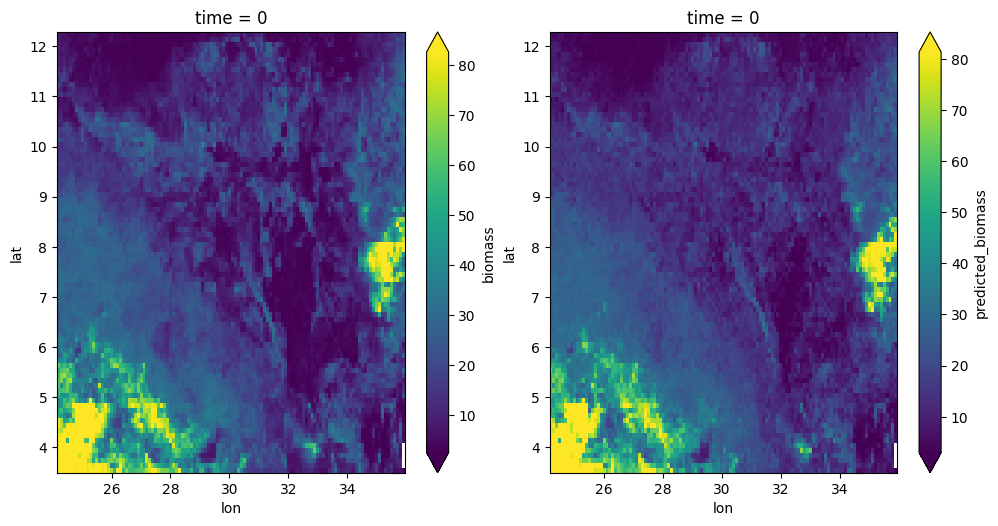

In [98]:
fig, ax = plt.subplots(1,2 , figsize = (10,5))
plt.tight_layout()

xarr.biomass.plot(
    ax = ax[0],
    x = 'lon',
    y = 'lat',
    robust = True
)

xarr.predicted_biomass.plot(
    ax = ax[1],
    x = 'lon',
    y = 'lat',
    robust = True
)


In [43]:
time_start = ee.Date('2015')
time_end = ee.Date('2016')

In [44]:
ndvi = (
    ee.ImageCollection("MODIS/061/MOD13A2")
    .select('NDVI','EVI')
    .filterDate(time_start, time_end)
    .mean().rename('ndvi', 'evi')
)

In [45]:
lai = (
    ee.ImageCollection("MODIS/061/MOD15A2H")
    .select('Lai_500m', 'Fpar_500m')
    .filterDate(time_start, time_end)
    .mean().rename('lai', 'fpar')
)


In [46]:
temp = (
    ee.ImageCollection("MODIS/061/MYD11A2")
    .select('LST_Day_1km')
    .filterDate(time_start, time_end)
    .mean().rename('temp')
)


In [47]:
pr = (
    ee.ImageCollection("NASA/GPM_L3/IMERG_MONTHLY_V07")
    .select('precipitation')
    .filterDate(time_start, time_end)
    .sum().rename('pr')
)

In [48]:
lc = (
    ee.ImageCollection("MODIS/061/MCD12Q1")
    .select('LC_Type1')
    .filterDate(time_start, time_end)
    .first().rename('lc')
)

In [49]:
stack2015 = ee.Image.cat([
    ndvi, lai, temp, pr, lc
])

stack2015

In [51]:
ds2015 = xr.open_dataset(
    stack2015,
    engine = 'ee',
    crs = 'EPSG:4326',
    scale = 0.1,
    geometry = border
)

In [52]:
df2015 = ds2015.to_dataframe().dropna()
df2015

ndvi          evi        lai       fpar  \
time lon       lat                                                         
0    24.200723 3.537472   8016.391113  4970.130371  51.108696  80.760872   
               3.637472   7945.391113  5062.434570  49.521740  79.804344   
               3.737472   8211.608398  4987.000000  52.673912  82.717392   
               3.837472   8071.478027  5029.608887  50.739132  81.304344   
               3.937472   7864.043457  5085.826172  52.869564  83.326088   
...                               ...          ...        ...        ...   
     35.900723 11.837472  5298.173828  3190.000000  17.152174  45.673912   
               11.937472  4827.956543  2842.913086  14.782609  41.282608   
               12.037472  4627.913086  2679.826172  14.021739  39.869564   
               12.137472  4588.086914  2684.826172  13.782609  40.956520   
               12.237472  4467.391113  2690.434814  13.152174  39.739132   

                                  temp     pr    lc  
time lon       lat                                   
0    24.200723 3.537472   15062.782227  2.161   2.0  
               3.637472   15076.326172  2.176   2.0  
               3.737472   15074.413086  2.221   2.0  
               3.837472   15077.913086  2.194   2.0  
               3.937472   15085.108398  2.202   2.0  
...                                ...    ...   ...  
     35.900723 11.837472  15540.630859  1.831  10.0  
               11.937472  15688.608398  1.664  12.0  
               12.037472  15723.608398  1.615  12.0  
               12.137472  15718.521484  1.504  10.0  
               12.237472  15702.108398  1.488  12.0  

[10379 rows x 7 columns]

In [53]:
df2015['biomass2015'] = model.predict(df2015[['ndvi', 'lai', 'temp', 'pr', 'lc', 'fpar', 'evi']])

df2015

ndvi          evi        lai       fpar  \
time lon       lat                                                         
0    24.200723 3.537472   8016.391113  4970.130371  51.108696  80.760872   
               3.637472   7945.391113  5062.434570  49.521740  79.804344   
               3.737472   8211.608398  4987.000000  52.673912  82.717392   
               3.837472   8071.478027  5029.608887  50.739132  81.304344   
               3.937472   7864.043457  5085.826172  52.869564  83.326088   
...                               ...          ...        ...        ...   
     35.900723 11.837472  5298.173828  3190.000000  17.152174  45.673912   
               11.937472  4827.956543  2842.913086  14.782609  41.282608   
               12.037472  4627.913086  2679.826172  14.021739  39.869564   
               12.137472  4588.086914  2684.826172  13.782609  40.956520   
               12.237472  4467.391113  2690.434814  13.152174  39.739132   

                                  temp     pr    lc  biomass2015  
time lon       lat                                                
0    24.200723 3.537472   15062.782227  2.161   2.0    76.248543  
               3.637472   15076.326172  2.176   2.0    70.438087  
               3.737472   15074.413086  2.221   2.0    90.701851  
               3.837472   15077.913086  2.194   2.0    82.966301  
               3.937472   15085.108398  2.202   2.0    82.586136  
...                                ...    ...   ...          ...  
     35.900723 11.837472  15540.630859  1.831  10.0     9.421988  
               11.937472  15688.608398  1.664  12.0    12.678390  
               12.037472  15723.608398  1.615  12.0    13.399200  
               12.137472  15718.521484  1.504  10.0    16.121244  
               12.237472  15702.108398  1.488  12.0     8.309377  

[10379 rows x 8 columns]

In [54]:
xarr2015 = df2015.to_xarray().sortby('lon').sortby('lat')

xarr2015

<xarray.Dataset> Size: 334kB
Dimensions:      (time: 1, lon: 118, lat: 88)
Coordinates:
  * time         (time) int64 8B 0
  * lon          (lon) float64 944B 24.2 24.3 24.4 24.5 ... 35.6 35.7 35.8 35.9
  * lat          (lat) float64 704B 3.537 3.637 3.737 ... 12.04 12.14 12.24
Data variables:
    ndvi         (time, lon, lat) float32 42kB 8.016e+03 7.945e+03 ... 4.467e+03
    evi          (time, lon, lat) float32 42kB 4.97e+03 5.062e+03 ... 2.69e+03
    lai          (time, lon, lat) float32 42kB 51.11 49.52 52.67 ... 13.78 13.15
    fpar         (time, lon, lat) float32 42kB 80.76 79.8 82.72 ... 40.96 39.74
    temp         (time, lon, lat) float32 42kB 1.506e+04 1.508e+04 ... 1.57e+04
    pr           (time, lon, lat) float32 42kB 2.161 2.176 2.221 ... 1.504 1.488
    lc           (time, lon, lat) float32 42kB 2.0 2.0 2.0 ... 12.0 10.0 12.0
    biomass2015  (time, lon, lat) float32 42kB 76.25 70.44 90.7 ... 16.12 8.309

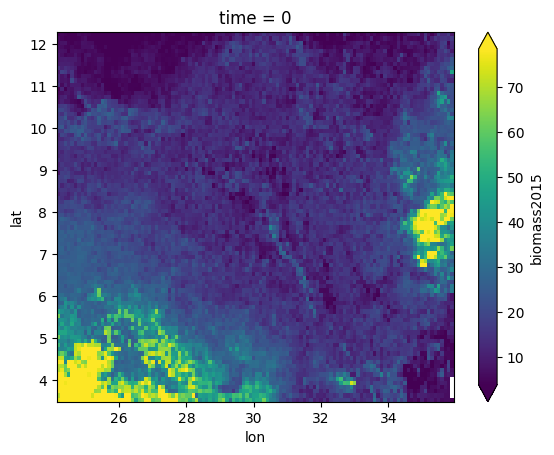

In [55]:
xarr2015.biomass2015.plot(
    x = 'lon',
    y = 'lat',
    robust = True
)